In [ ]:
!pip install bayesian-optimization
!pip install scikit-optimize
!pip install hyperopt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from skopt import forest_minimize
from skopt.space import Real



## Patient response function and Bayesian optimzer algorithm functions.

In [ ]:
import pandas as pd
import numpy as np
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from skopt import forest_minimize
from skopt.space import Real

def run_optimization_comparison(num_simulation_trials: int, random_seed, search_boundaries: dict) -> pd.DataFrame:

    # Ideal parameters for Pupillometry
    ideal_amp_pup = 4.4
    amp_spread_pup = 0.5

    # Ideal parameters for HRV
    ideal_amp_hrv = 4.0
    amp_spread_hrv = 0.4

    # Shared interaction targets: (10Hz, 500us) and (25Hz, 100us)
    optima = [(10.0, 500.0), (25.0, 100.0)]
    freq_spread, width_spread = 5.0, 100.0

    def realistic_patient_curve(amplitude, frequency, pulse_width):
        v_amp = np.random.uniform(-0.05, 0.05)
        v_freq = np.random.uniform(-0.3, 0.3)
        v_width = np.random.uniform(-1, 1)

        # We calculate response based on proximity to the two optimal (Freq, Width) pairs
        def get_interdependence_score(f, w):
            scores = []
            for (opt_f, opt_w) in optima:
                dist = (((f - (opt_f + v_freq))**2 / (2 * freq_spread**2)) +
                        ((w - (opt_w + v_width))**2 / (2 * width_spread**2)))
                scores.append(np.exp(-dist))
            return max(scores) # Return strongest response

        inter_score = get_interdependence_score(frequency, pulse_width)

        # Pupillometry Calculation
        amp_comp_pup = np.exp(-((amplitude - (ideal_amp_pup + v_amp))**2) / (2 * amp_spread_pup**2))
        pup_score = 100 * amp_comp_pup * inter_score

        # HRV Calculation
        amp_comp_hrv = np.exp(-((amplitude - (ideal_amp_hrv + v_amp))**2) / (2 * amp_spread_hrv**2))
        erp_score = 100 * amp_comp_hrv * inter_score

        return {'pup': max(0, pup_score), 'erp': max(0, erp_score)}

    def multi_objective_wrapper(amplitude, frequency, pulse_width):
        results = realistic_patient_curve(amplitude, frequency, pulse_width)
        w_pup, w_hrv = 0.5, 0.5
        return w_pup * results['pup'] + w_hrv * results['erp']

    # --- Bayesian Optimization ---
    optimizer_multi = BayesianOptimization(
        f=multi_objective_wrapper,
        pbounds=search_boundaries,
        random_state=random_seed,
        verbose=0
    )
    print(f"\n--- Starting Bayesian Optimization ({num_simulation_trials} iterations) ---")
    optimizer_multi.maximize(init_points=max(1, num_simulation_trials // 10), n_iter=num_simulation_trials - max(1, num_simulation_trials // 10))

    # --- TPE Optimization ---
    def objective_tpe(params):
        score = multi_objective_wrapper(params['amplitude'], params['frequency'], params['pulse_width'])
        return {'loss': -score, 'status': STATUS_OK}

    space = {
        'amplitude': hp.uniform('amplitude', search_boundaries['amplitude'][0], search_boundaries['amplitude'][1]),
        'frequency': hp.uniform('frequency', search_boundaries['frequency'][0], search_boundaries['frequency'][1]),
        'pulse_width': hp.uniform('pulse_width', search_boundaries['pulse_width'][0], search_boundaries['pulse_width'][1])
    }
    trials = Trials()
    print(f"\n--- Starting TPE Optimization ({num_simulation_trials} iterations) ---")
    fmin(fn=objective_tpe, space=space, algo=tpe.suggest, max_evals=num_simulation_trials, trials=trials, rstate=np.random.default_rng(random_seed))

    # --- SMAC Optimization ---
    def objective_smac(params):
        return -multi_objective_wrapper(*params)

    space_smac = [
        Real(search_boundaries['amplitude'][0], search_boundaries['amplitude'][1], name='amplitude'),
        Real(search_boundaries['frequency'][0], search_boundaries['frequency'][1], name='frequency'),
        Real(search_boundaries['pulse_width'][0], search_boundaries['pulse_width'][1], name='pulse_width')
    ]
    print(f"\n--- Starting SMAC Optimization with Random Forest ({num_simulation_trials} iterations) ---")
    res_smac = forest_minimize(func=objective_smac, dimensions=space_smac, n_calls=num_simulation_trials, random_state=random_seed, base_estimator='RF')

    # --- Random Search ---
    np.random.seed(random_seed)
    best_random_score = -np.inf
    best_random_params = {}
    print(f"\n--- Starting Random Search Optimization ({num_simulation_trials} iterations) ---")
    for _ in range(num_simulation_trials):
        a, f, w = [np.random.uniform(search_boundaries[k][0], search_boundaries[k][1]) for k in ['amplitude', 'frequency', 'pulse_width']]
        current_score = multi_objective_wrapper(a, f, w)
        if current_score > best_random_score:
            best_random_score = current_score
            best_random_params = {'amplitude': a, 'frequency': f, 'pulse_width': w}

    comparison_data = {
        'Method': ['Bayesian Optimization', 'TPE Optimization', 'SMAC Optimization', 'Random Search'],
        'Best Combined Score': [optimizer_multi.max['target'], -trials.best_trial['result']['loss'], -res_smac.fun, best_random_score],
        'Optimal Amplitude (mA)': [optimizer_multi.max['params']['amplitude'], trials.argmin['amplitude'], res_smac.x[0], best_random_params['amplitude']],
        'Optimal Frequency (Hz)': [optimizer_multi.max['params']['frequency'], trials.argmin['frequency'], res_smac.x[1], best_random_params['frequency']],
        'Optimal Pulse Width (us)': [optimizer_multi.max['params']['pulse_width'], trials.argmin['pulse_width'], res_smac.x[2], best_random_params['pulse_width']]
    }
    return pd.DataFrame(comparison_data)

In [ ]:
num_trials_depth = 40
num_runs = 40

#taVNS search boundaires
taVNS_search_boundaries = {
    'amplitude': (3.0, 5.0),
    'frequency': (5.0, 50.0),
    'pulse_width': (50.0, 600.0)
}

all_comparison_results = []

for i in range(num_runs):
  print(f"\rRunning Optimization Comparison (Trial {i+1}/{num_runs})...", end="")
  run_results = run_optimization_comparison(num_trials_depth, i, taVNS_search_boundaries)
  all_comparison_results.append(run_results)

final_comparison_df = pd.concat(all_comparison_results, ignore_index=True)

print("\n--- Combined Optimization Comparison Results ---")
display(final_comparison_df.head())
final_comparison_df.to_csv('combined_optimization_results.csv', index=False)

## Visualization of Optimization Comparison Results

This graph compares the performance and consistency of Bayesian Optimization, TPE, and SMAC based on their 'Best Combined Score' across multiple runs.

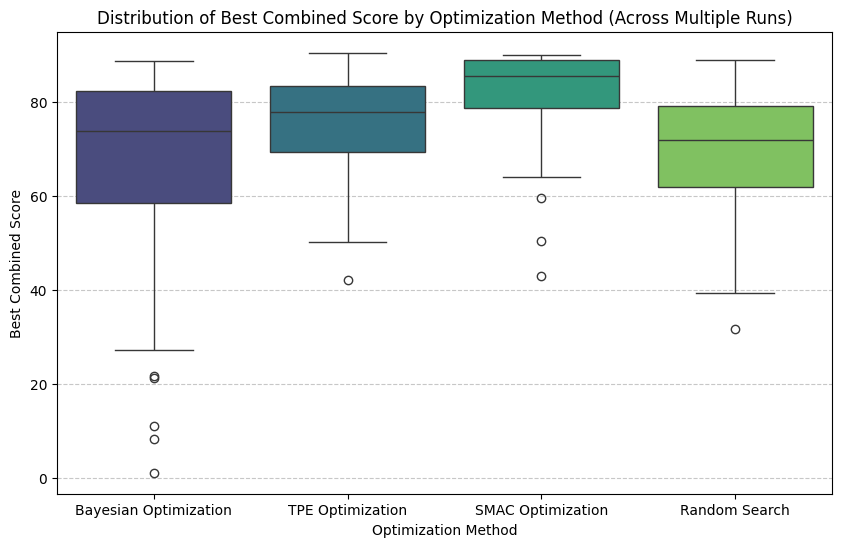

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Best Combined Score', data=final_comparison_df, palette='viridis', hue='Method', legend=False)
plt.title('Distribution of Best Combined Score by Optimization Method (Across Multiple Runs)')
plt.xlabel('Optimization Method')
plt.ylabel('Best Combined Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Statistics about Optimization Methods


In [ ]:
import pandas as pd

# Group by 'Method' and calculate descriptive statistics for 'Best Combined Score'
score_stats = final_comparison_df.groupby('Method')['Best Combined Score'].agg(['mean', 'std', 'min', 'max']).reset_index()
print("\n--- Statistics for Best Combined Score ---")
display(score_stats)

# Calculate descriptive statistics for each optimal parameter
parameters = ['Optimal Amplitude (mA)', 'Optimal Frequency (Hz)', 'Optimal Pulse Width (us)']

all_param_stats = []
for param in parameters:
    param_stats = final_comparison_df.groupby('Method')[param].agg(['mean', 'std', 'min', 'max']).reset_index()
    param_stats['Parameter'] = param
    all_param_stats.append(param_stats)

# Concatenate all parameter statistics into a single DataFrame
final_param_stats_df = pd.concat(all_param_stats, ignore_index=True)

print("\n--- Statistics for Optimal Parameters ---")
display(final_param_stats_df)



--- Statistics for Best Combined Score ---


,Method,mean,std,min,max
0,Bayesian Optimization,65.504943,24.431775,1.190522,88.761800
1,Random Search,68.554587,13.653625,31.707319,88.955673
2,SMAC Optimization,81.336802,11.063307,43.060729,89.948094
3,TPE Optimization,75.074955,11.883261,42.141233,90.460543



--- Statistics for Optimal Parameters ---


,Method,mean,std,min,max,Parameter
0,Bayesian Optimization,4.158087,0.133743,3.846184,4.520727,Optimal Amplitude (mA)
1,Random Search,4.174776,0.219024,3.735235,4.605907,Optimal Amplitude (mA)
2,SMAC Optimization,4.142931,0.138184,3.806632,4.717515,Optimal Amplitude (mA)
3,TPE Optimization,4.096581,0.183531,3.758101,4.514139,Optimal Amplitude (mA)
4,Bayesian Optimization,17.699699,7.356636,6.787514,27.558523,Optimal Frequency (Hz)
5,Random Search,16.195807,8.334194,5.530188,30.323285,Optimal Frequency (Hz)
6,SMAC Optimization,17.532585,8.047709,6.000358,27.286539,Optimal Frequency (Hz)
7,TPE Optimization,18.567368,7.435645,8.167534,27.536384,Optimal Frequency (Hz)
8,Bayesian Optimization,321.926005,186.440319,53.544859,570.069477,Optimal Pulse Width (us)
9,Random Search,342.158995,193.569301,73.502876,564.624521,Optimal Pulse Width (us)


Statistics for best combined scores saved to 'best_combined_score_statistics.csv'
Statistics for optimal parameters saved to 'optimal_parameter_statistics.csv'


## ANOVA Test for Optimization Methods


In [ ]:
from scipy import stats

# Extract the 'Best Combined Score' for each optimization method
bayesian_scores = final_comparison_df[final_comparison_df['Method'] == 'Bayesian Optimization']['Best Combined Score']
tpe_scores = final_comparison_df[final_comparison_df['Method'] == 'TPE Optimization']['Best Combined Score']
smac_scores = final_comparison_df[final_comparison_df['Method'] == 'SMAC Optimization']['Best Combined Score']
random_search_scores = final_comparison_df[final_comparison_df['Method'] == 'Random Search']['Best Combined Score']

# Perform one-way ANOVA including Random Search
f_statistic, p_value = stats.f_oneway(bayesian_scores, tpe_scores, smac_scores, random_search_scores)

print(f"--- ANOVA Results for Best Combined Score ---")
print(f"F-statistic: {f_statistic:.5f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"Conclusion: Reject the null hypothesis. There is a statistically significant difference (p < {alpha}) in the mean 'Best Combined Score' among the optimization methods.")
else:
    print(f"Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference (p >= {alpha}) in the mean 'Best Combined Score' among the optimization methods.")

--- ANOVA Results for Best Combined Score ---
F-statistic: 7.59857
P-value: 0.00009
Conclusion: Reject the null hypothesis. There is a statistically significant difference (p < 0.05) in the mean 'Best Combined Score' among the optimization methods.


## Post-Hoc Analysis: Tukey's HSD Test

Since ANOVA indicates a statistically significant difference among the optimization methods, a post-hoc test is done to identify  which pairs of methods have statistically different mean Best Combined Score.

--- Tukey's HSD Post-Hoc Test Results ---
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
        group1              group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------
Bayesian Optimization     Random Search   3.0496 0.8338  -6.3449 12.4442  False
Bayesian Optimization SMAC Optimization  15.8319 0.0001   6.4373 25.2265   True
Bayesian Optimization  TPE Optimization     9.57 0.0441   0.1754 18.9646   True
        Random Search SMAC Optimization  12.7822  0.003   3.3876 22.1768   True
        Random Search  TPE Optimization   6.5204 0.2761  -2.8742  15.915  False
    SMAC Optimization  TPE Optimization  -6.2618 0.3112 -15.6564  3.1327  False
-------------------------------------------------------------------------------


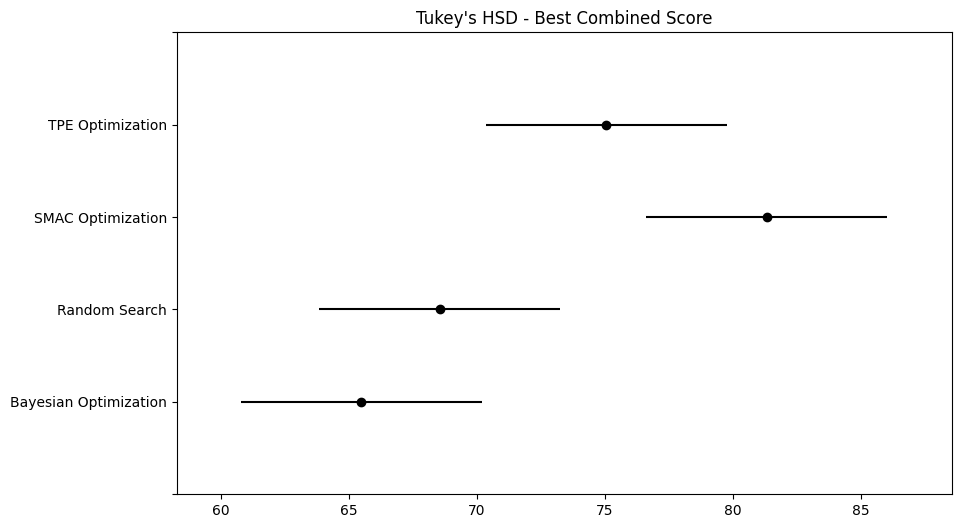

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Combine all scores into a single array and create corresponding group labels
all_scores = pd.concat([bayesian_scores, tpe_scores, smac_scores, random_search_scores])
groups = ['Bayesian Optimization'] * len(bayesian_scores) + \
         ['TPE Optimization'] * len(tpe_scores) + \
         ['SMAC Optimization'] * len(smac_scores) + \
         ['Random Search'] * len(random_search_scores)

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=all_scores, groups=groups, alpha=0.05)

print("--- Tukey's HSD Post-Hoc Test Results ---")
print(tukey_result)

# Results visualized
tukey_result.plot_simultaneous()
plt.title("Tukey's HSD - Best Combined Score")
plt.show()